# SHA256 Pattern Research
## 1000 random passwords
## word size = 32bits * 8

#### import module & set root path

In [25]:
from diffusion_hash_inv.utils.project_root import get_project_root
import os
try:
    from diffusion_hash_inv.utils import FileIO
except ImportError as e:
    print(f"Error importing FileIO: {e}")

project_root = get_project_root()
print(project_root)

/Users/choisoonwook/Desktop/Research/Diffusion HASH/Diffusion_HASH_inverse


In [ ]:
import pandas as pd
data_path = project_root / "output" / "xlsx"
data_file = data_path / "256" / "sha256_256_2025-09-10 21-14-15.xlsx"
df = pd.read_excel(str(data_file), skiprows=4, header=None)
cols = (
    ["field","nbr","input"] + [f"M{i}" for i in range(16)] + [f"H0_{i}" for i in range(8)] + [f"K0_{i}" for i in range(64)]
    + [f"W{i}" for i in range(64)] + ["a","b","c","d","e","f","g","h"]
    + [f"I{i}_{suffix}" for i in range(64) for suffix in ["t1","t2","a","b","c","d","e","f","g","h"]]
    + [f"H1_{i}" for i in range(8)]
)
df.columns = cols

print(df.head())

   field  nbr                             input          M0          M1  \
0      0    1  !]/k,$_A*qItd0 y1|akkoz\rYw8c#6z  0x215d2f6b  0x2c245f41   
1      1    2  &|z"-?adNu yhVc J)l|{I%@<:E0k~W<  0x267c7a22  0x2d3f6164   
2      2    3  N#,l2*Szwl7B":ze&x22M$EQi3tBgHPM  0x4e232c6c  0x322a537a   
3      3    4  jV( FGnKW,$`(u5%}`sPl"0.\A0`z+;p  0x6a562820  0x46476e4b   
4      4    5  uCun8`8ILAf(\LI\I[!CYBKSQ6,$P0W/  0x7543756e  0x38603849   

           M2          M3          M4          M5          M6  ...  \
0  0x2a714974  0x64302079  0x317c616b  0x6b6f7a5c  0x72597738  ...   
1  0x4e752079  0x68566320  0x4a296c7c  0x7b492540  0x3c3a4530  ...   
2  0x776c3742  0x223a7a65  0x26783232  0x4d244551  0x69337442  ...   
3  0x572c2460  0x28753525  0x7d607350  0x6c22302e  0x5c413060  ...   
4  0x4c416628  0x5c4c495c  0x495b2143  0x59424b53  0x51362c24  ...   

        I63_g       I63_h        H1_0        H1_1        H1_2        H1_3  \
0  0x5345839c  0x76c13e5a  0xd6a3ada1  0x781cb1f6  

In [ ]:
data_path = project_root / "output" / "xlsx"
data_file = data_path / "256" / "sha256_256_2025-09-10 21-14-15.xlsx"
df = pd.read_excel(str(data_file), skiprows=4, header=None)
cols = (
    ["field","nbr","input"] + [f"M{i}" for i in range(16)] + [f"H0_{i}" for i in range(8)] + [f"K0_{i}" for i in range(64)]
    + [f"W{i}" for i in range(64)] + ["a","b","c","d","e","f","g","h"]
    + [f"I{i}_{suffix}" for i in range(64) for suffix in ["t1","t2","a","b","c","d","e","f","g","h"]]
    + [f"H1_{i}" for i in range(8)]
)
df.columns = cols

print(df.head())

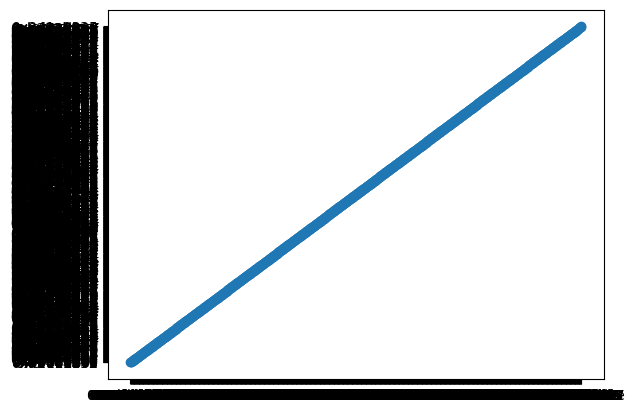

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(df['I0_a'], df['I1_a'])

In [11]:
cols1 = (
    ["a","b","c","d","e","f","g","h"]
    + [f"I{i}_{suffix}" for i in range(64) for suffix in ["t1","t2","a","b","c","d","e","f","g","h"]]
    + [f"H1_{i}" for i in range(8)]
)
df1=df[cols1]
print(df1.head())

            a           b           c           d           e           f  \
0  0x6a09e667  0xbb67ae85  0x3c6ef372  0xa54ff53a  0x510e527f  0x9b05688c   
1  0x6a09e667  0xbb67ae85  0x3c6ef372  0xa54ff53a  0x510e527f  0x9b05688c   
2  0x6a09e667  0xbb67ae85  0x3c6ef372  0xa54ff53a  0x510e527f  0x9b05688c   
3  0x6a09e667  0xbb67ae85  0x3c6ef372  0xa54ff53a  0x510e527f  0x9b05688c   
4  0x6a09e667  0xbb67ae85  0x3c6ef372  0xa54ff53a  0x510e527f  0x9b05688c   

            g           h       I0_t1       I0_t2  ...       I63_g  \
0  0x1f83d9ab  0x5be0cd19  0x14d51cd3  0x08909ae5  ...  0x5345839c   
1  0x1f83d9ab  0x5be0cd19  0x19f4678a  0x08909ae5  ...  0x98191aa6   
2  0x1f83d9ab  0x5be0cd19  0x419b19d4  0x08909ae5  ...  0x57c4e995   
3  0x1f83d9ab  0x5be0cd19  0x5dce1588  0x08909ae5  ...  0x177c9def   
4  0x1f83d9ab  0x5be0cd19  0x68bb62d6  0x08909ae5  ...  0xe30c0c56   

        I63_h        H1_0        H1_1        H1_2        H1_3        H1_4  \
0  0x76c13e5a  0xd6a3ada1  0x781cb1f6  

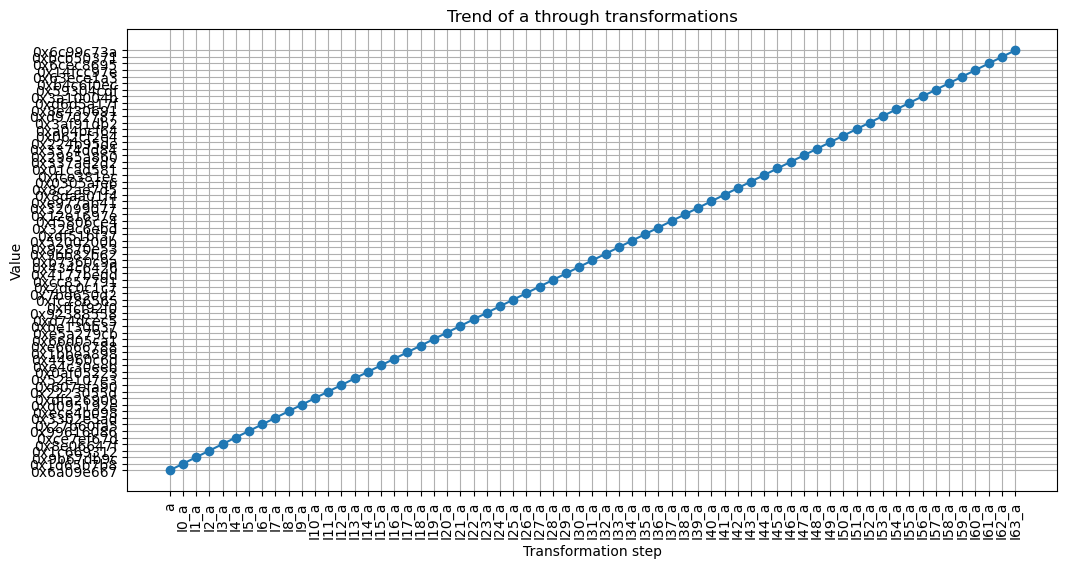

In [13]:
# trend a with first input

import pandas as pd
import matplotlib.pyplot as plt

variables = ['a'] + [f'I{i}_a' for i in range(64)]

row = df.iloc[0][variables]

plt.figure(figsize=(12,6))
plt.plot(range(len(variables)), row.values, marker='o')
plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of a through transformations')
plt.grid(True)
plt.show()


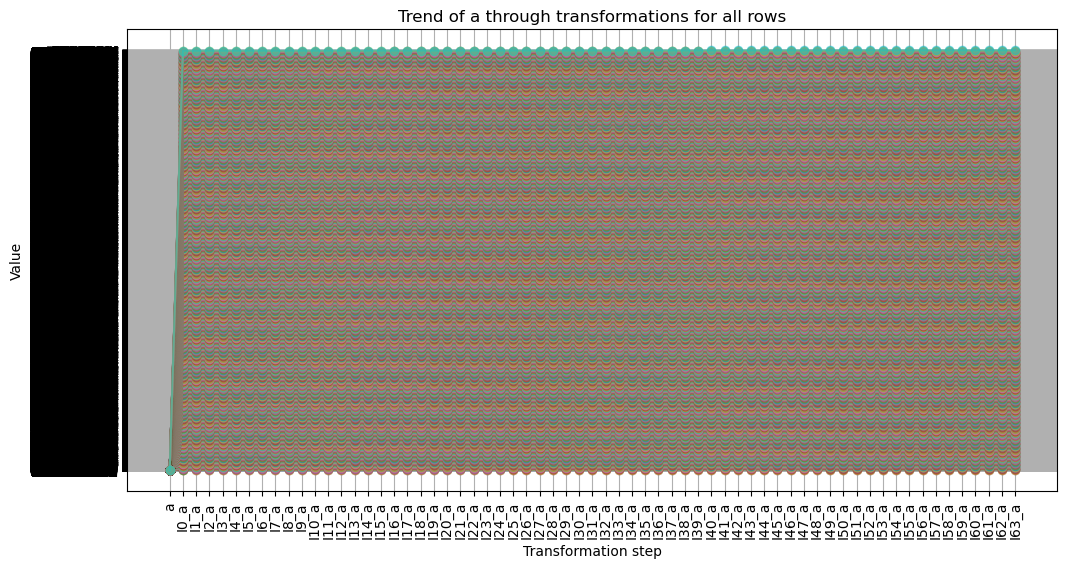

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

variables = ['a'] + [f'I{i}_a' for i in range(64)]

plt.figure(figsize=(12,6))

# 모든 행을 한 번에 플롯
for idx in range(len(df)):
    row = df.iloc[idx][variables]
    plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5)  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of a through transformations for all rows')
plt.grid(True)
plt.show()

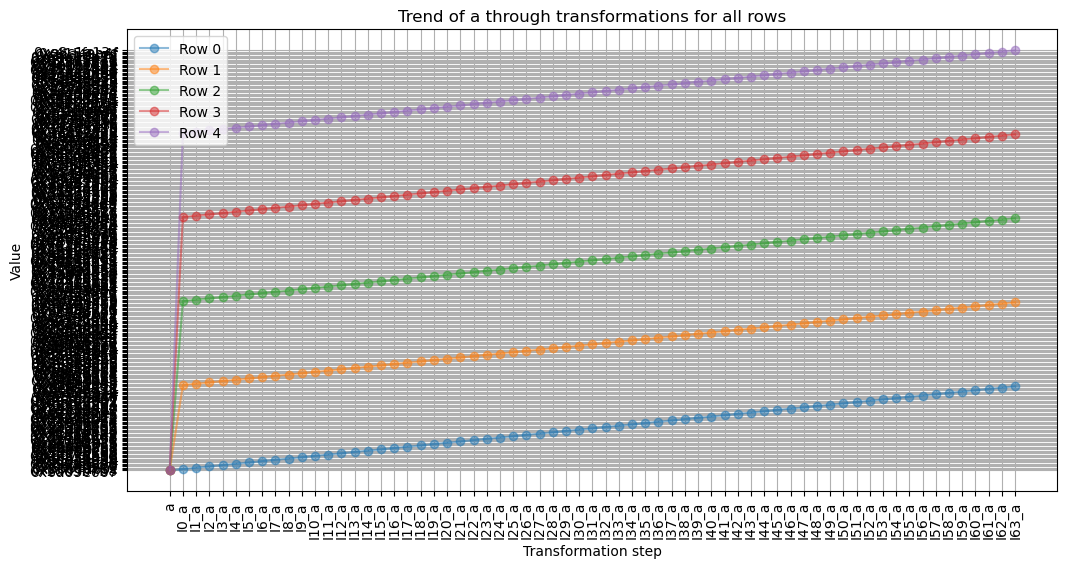

In [25]:
# row0 ~ row5

import pandas as pd
import matplotlib.pyplot as plt

variables = ['a'] + [f'I{i}_a' for i in range(64)]

plt.figure(figsize=(12,6))

for idx in range(5):
    row = df.iloc[idx][variables]
    plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5, label=f'Row {idx}')  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of a through transformations for all rows')
plt.grid(True)
plt.legend()
plt.show()

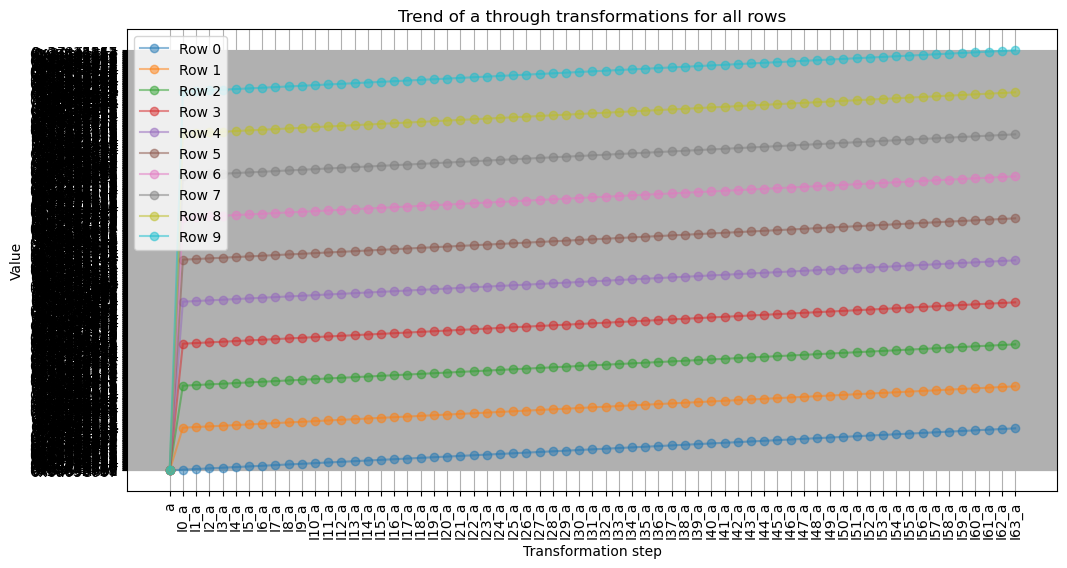

In [26]:
# row0~row9

import pandas as pd
import matplotlib.pyplot as plt

variables = ['a'] + [f'I{i}_a' for i in range(64)]

plt.figure(figsize=(12,6))

for idx in range(10):
    row = df.iloc[idx][variables]
    plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5, label=f'Row {idx}')  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of a through transformations for all rows')
plt.grid(True)
plt.legend()
plt.show()

In [18]:
# trend a with mean

import numpy as np

df1=df[variables]

# 16진수 -> integer
df1_numeric = df1.applymap(lambda x: int(x, 16))

mean_values = df1_numeric.mean(axis=0)

print(mean_values)

a        1.779034e+09
I0_a     1.256006e+09
I1_a     2.193924e+09
I2_a     2.117095e+09
I3_a     2.200936e+09
             ...     
I59_a    2.152220e+09
I60_a    2.131884e+09
I61_a    2.146859e+09
I62_a    2.131776e+09
I63_a    2.125925e+09
Length: 65, dtype: float64


In [16]:
df[variables].head()

,a,I0_a,I1_a,I2_a,I3_a,I4_a,I5_a,I6_a,I7_a,I8_a,...,I54_a,I55_a,I56_a,I57_a,I58_a,I59_a,I60_a,I61_a,I62_a,I63_a
0,0x6a09e667,0x1d65b7b8,0x9b67db9c,0x1c669312,0x8e06647f,0xce7ef67d,0x99616086,0x27b60fa5,0x3302e5ad,0xece4b098,...,0x8e430691,0xd6d5a17f,0x3a10004b,0x59304cdf,0xb4c6f0ec,0x63ece1a3,0x14fcc97e,0x6cec8695,0xbcb50371,0x6c99c73a
1,0x6a09e667,0x2285026f,0xf11c1a33,0xffdc5e6b,0xa4ff6942,0xd8463de0,0x8fbadac9,0x83ec8bb5,0x30f09b31,0xc30ce744,...,0x213479c1,0xc4634597,0x4c8ebb09,0x0577c270,0xf3fdc3a1,0x6e8ae730,0x3cb1f714,0x81ad081e,0xba6836b2,0x4291bf42
2,0x6a09e667,0x4a2bb4b9,0x8f72ca72,0xdc6e4cea,0x81ef0076,0x8439db7a,0xa7a2fca9,0x01fa3a27,0xd354f9bf,0xd0b23807,...,0xe7a100ff,0x8567f298,0xfd4f7857,0xe5dc3894,0x24d55b9d,0x877d4bfe,0xf5a5bcf8,0x643b2ec2,0x0afa79f1,0x0acc203a
3,0x6a09e667,0x665eb06d,0x59e83b9c,0x5910bfb2,0x8aa4ee66,0x79398411,0x00d4f02d,0x17b0152c,0x35f2b377,0x80753c57,...,0x90a1f69f,0xd206f19e,0xea78fa9c,0xe5f9baa8,0x76a107cf,0xe74f53b4,0xbcd10e6d,0x80a3ff14,0xb82594ca,0xf107a035
4,0x6a09e667,0x714bfdbb,0x3b8b32c8,0x97527a29,0x42257ce2,0x3149a418,0x061d2a19,0x263d0ef6,0xb1c9ea3c,0xb1a8f105,...,0x9cd93551,0xb23712d2,0x0181ed38,0x3fc85e4d,0xb9e01b1a,0xe0411a73,0xc4dc1c7c,0x26a49b6f,0x415fea4f,0xe8c1a13c


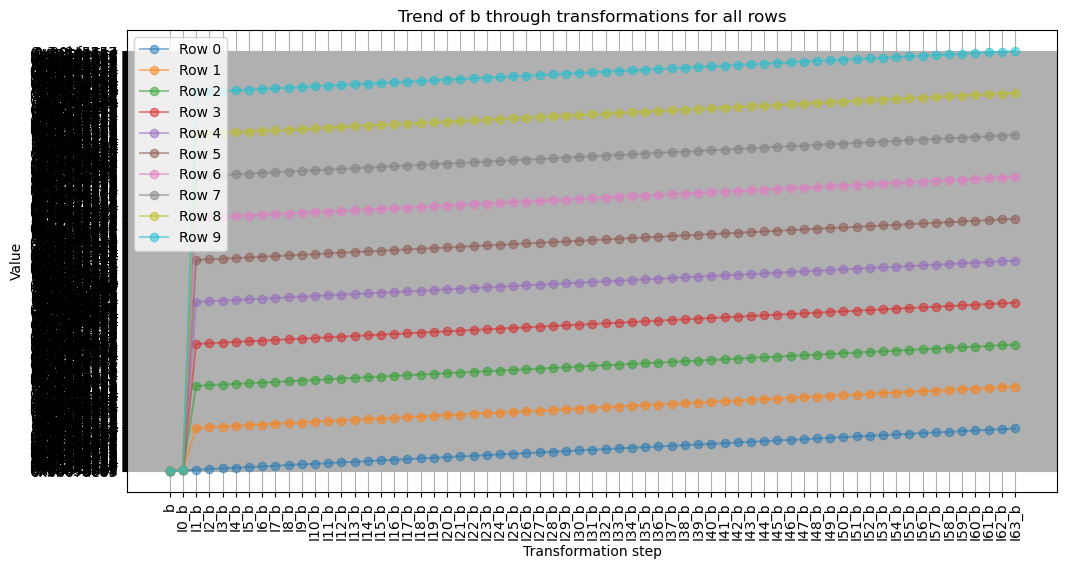

In [69]:
# b
# row0~row9

import pandas as pd
import matplotlib.pyplot as plt

variables = ['b'] + [f'I{i}_b' for i in range(64)]

plt.figure(figsize=(12,6))

for idx in range(10):
    row = df.iloc[idx][variables]
    plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5, label=f'Row {idx}')  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of b through transformations for all rows')
plt.grid(True)
plt.legend()
plt.show()

In [67]:
#df.head()
temp=['I60_b', 'I61_b', 'I62_b', 'I63_b']
df[temp].head()

,I60_b,I61_b,I62_b,I63_b
0,0x63ece1a3,0x14fcc97e,0x6cec8695,0xbcb50371
1,0x6e8ae730,0x3cb1f714,0x81ad081e,0xba6836b2
2,0x877d4bfe,0xf5a5bcf8,0x643b2ec2,0x0afa79f1
3,0xe74f53b4,0xbcd10e6d,0x80a3ff14,0xb82594ca
4,0xe0411a73,0xc4dc1c7c,0x26a49b6f,0x415fea4f


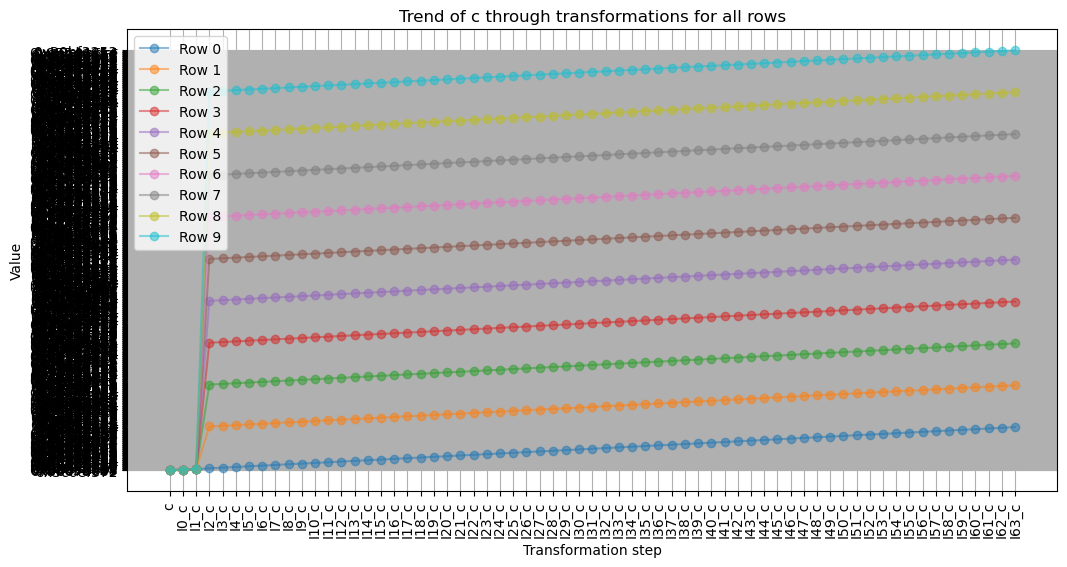

In [28]:
# c
# row0~row9

import pandas as pd
import matplotlib.pyplot as plt

variables = ['c'] + [f'I{i}_c' for i in range(64)]

plt.figure(figsize=(12,6))

for idx in range(10):
    row = df.iloc[idx][variables]
    plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5, label=f'Row {idx}')  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of c through transformations for all rows')
plt.grid(True)
plt.legend()
plt.show()

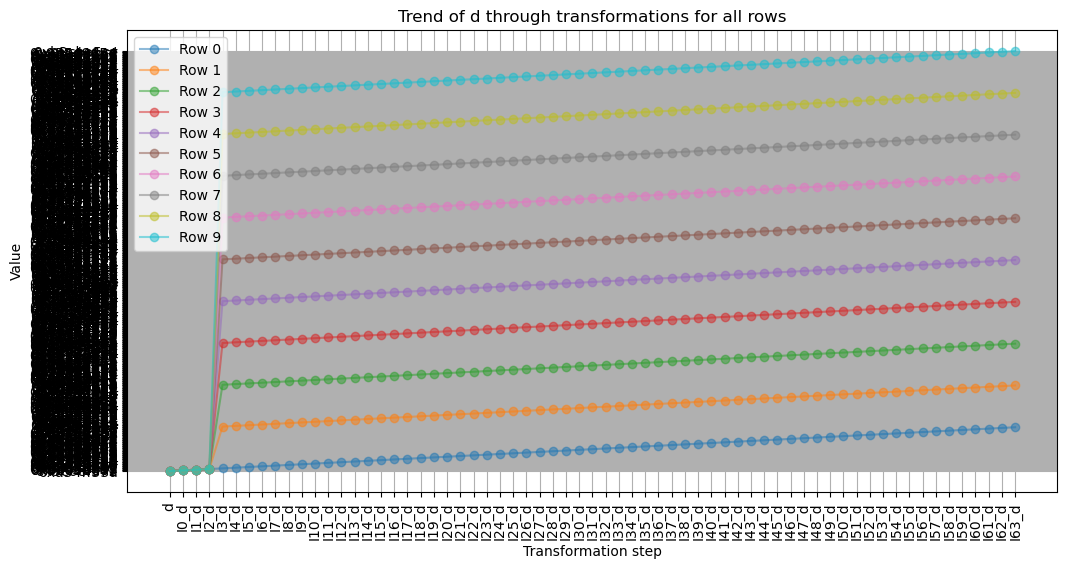

In [29]:
# d
# row0~row9

import pandas as pd
import matplotlib.pyplot as plt

variables = ['d'] + [f'I{i}_d' for i in range(64)]

plt.figure(figsize=(12,6))

for idx in range(10):
    row = df.iloc[idx][variables]
    plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5, label=f'Row {idx}')  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of d through transformations for all rows')
plt.grid(True)
plt.legend()
plt.show()

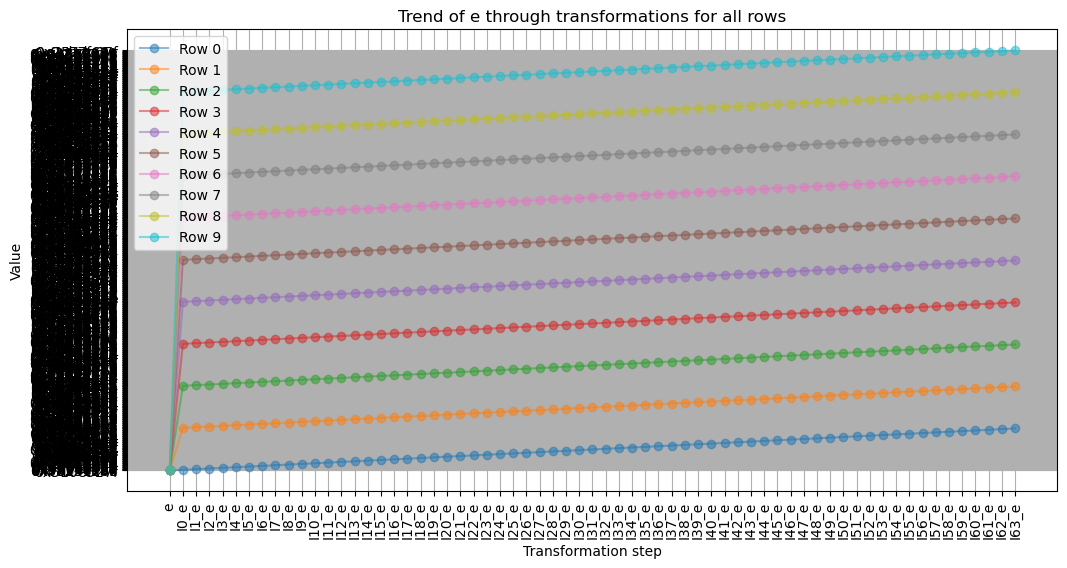

In [30]:
# e
# row0~row9

import pandas as pd
import matplotlib.pyplot as plt

variables = ['e'] + [f'I{i}_e' for i in range(64)]

plt.figure(figsize=(12,6))

for idx in range(10):
    row = df.iloc[idx][variables]
    plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5, label=f'Row {idx}')  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of e through transformations for all rows')
plt.grid(True)
plt.legend()
plt.show()

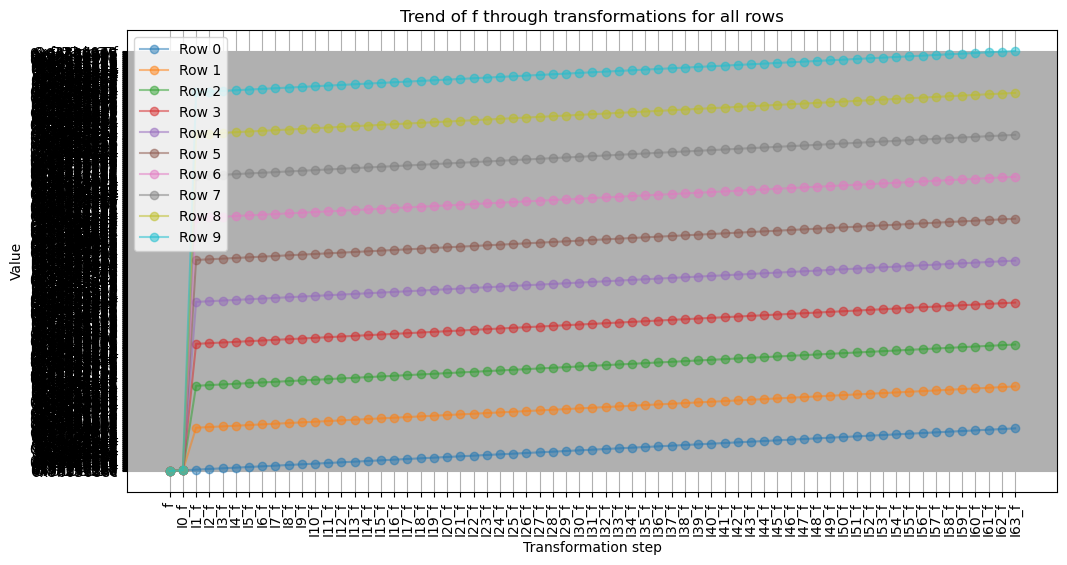

In [31]:
# f
# row0~row9

import pandas as pd
import matplotlib.pyplot as plt

variables = ['f'] + [f'I{i}_f' for i in range(64)]

plt.figure(figsize=(12,6))

for idx in range(10):
    row = df.iloc[idx][variables]
    plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5, label=f'Row {idx}')  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of f through transformations for all rows')
plt.grid(True)
plt.legend()
plt.show()

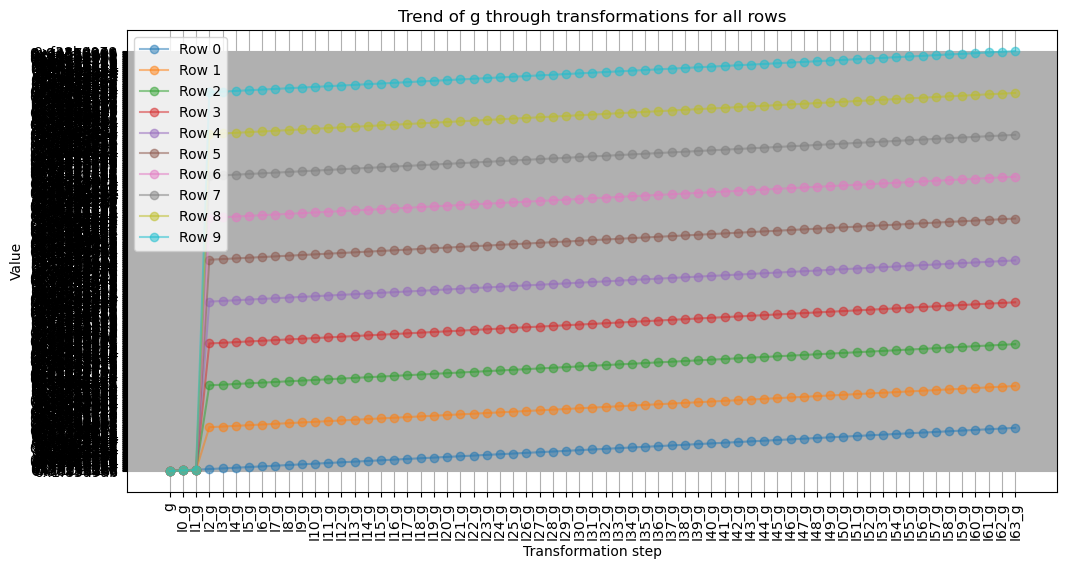

In [32]:
# g
# row0~row9

import pandas as pd
import matplotlib.pyplot as plt

variables = ['g'] + [f'I{i}_g' for i in range(64)]

plt.figure(figsize=(12,6))

for idx in range(10):
    row = df.iloc[idx][variables]
    plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5, label=f'Row {idx}')  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of g through transformations for all rows')
plt.grid(True)
plt.legend()
plt.show()

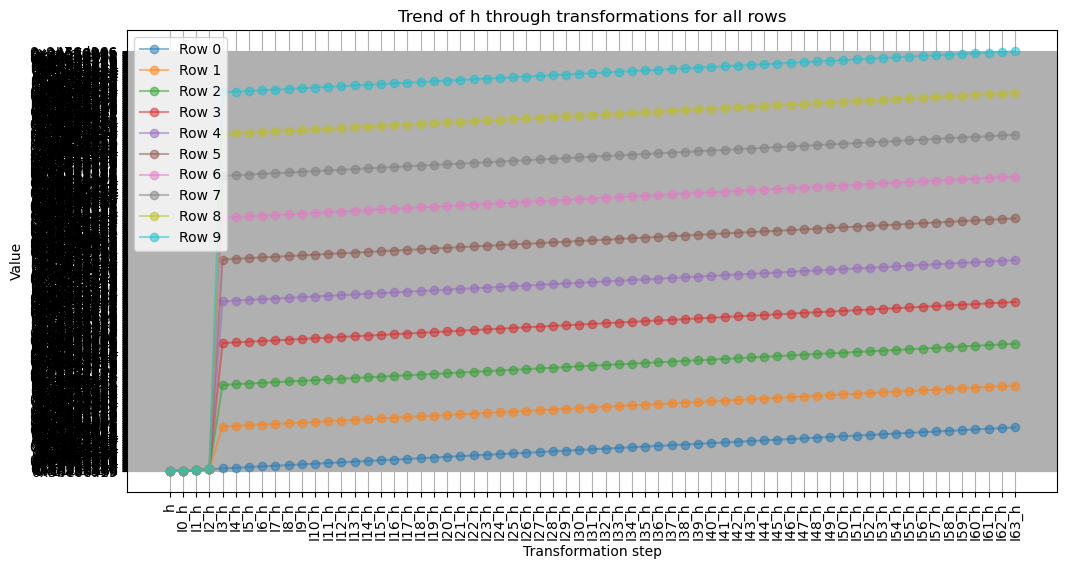

In [33]:
# h
# row0~row9

import pandas as pd
import matplotlib.pyplot as plt

variables = ['h'] + [f'I{i}_h' for i in range(64)]

plt.figure(figsize=(12,6))

for idx in range(10):
    row = df.iloc[idx][variables]
    plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5, label=f'Row {idx}')  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=90)
plt.xlabel('Transformation step')
plt.ylabel('Value')
plt.title('Trend of h through transformations for all rows')
plt.grid(True)
plt.legend()
plt.show()

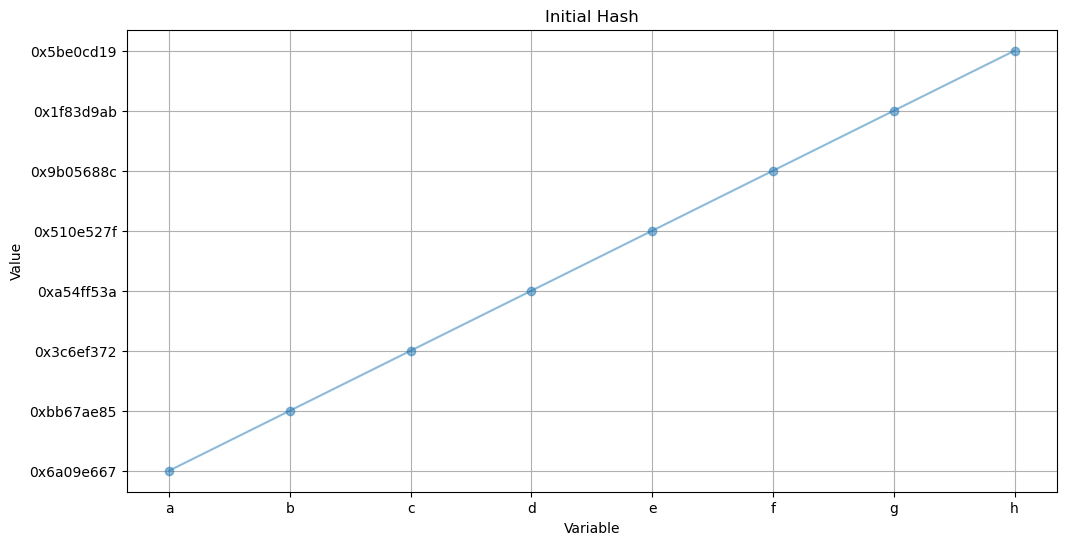

In [58]:
plt.figure(figsize=(12,6))

row = df.iloc[0][variables]
plt.plot(range(len(variables)), row.values, marker='o', alpha=0.5)  # alpha로 투명도 조절

plt.xticks(range(len(variables)), variables, rotation=0)
plt.xlabel('Variable')
plt.ylabel('Value')
plt.title('Initial Hash')
plt.grid(True)
plt.show()

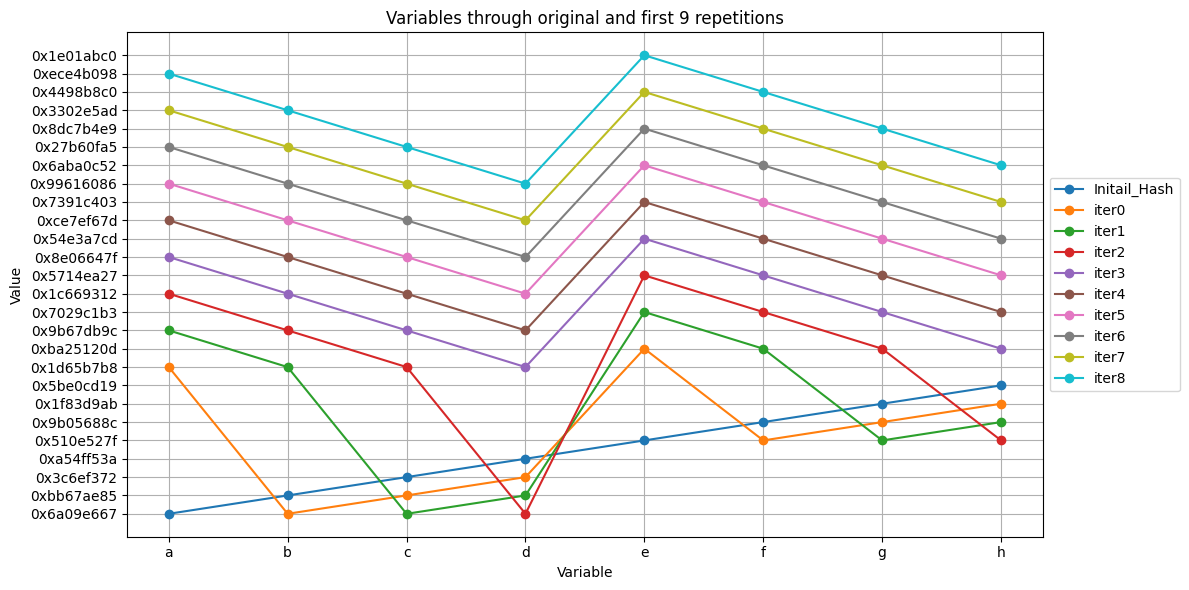

In [35]:
# plot with only 1st row

import matplotlib.pyplot as plt

variables = ['a','b','c','d','e','f','g','h']

# iter0 to iter8
num_repeats = 10

plt.figure(figsize=(12,6))

# 반복 0: 원래 변수
row_values = df.iloc[0][variables].values
plt.plot(variables, row_values, marker='o', label='Initail_Hash')

# 반복 1~9
for r in range(1, num_repeats):
    repeat_vars = [f'I{r-1}_{v}' for v in variables]
    row_values = df.iloc[0][repeat_vars].values
    plt.plot(variables, row_values, marker='o', label=f'iter{r-1}')

plt.xlabel('Variable')
plt.ylabel('Value')
plt.title('Variables through original and first 9 repetitions')
plt.grid(True)

# 범례를 그림 오른쪽 밖에 표시
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


['I0_a', 'I0_b', 'I0_c', 'I0_d', 'I0_e', 'I0_f', 'I0_g', 'I0_h']
['0x2285026f' '0x6a09e667' '0xbb67ae85' '0x3c6ef372' '0xbf445cc4'
 '0x510e527f' '0x9b05688c' '0x1f83d9ab']
['I1_a', 'I1_b', 'I1_c', 'I1_d', 'I1_e', 'I1_f', 'I1_g', 'I1_h']
['0xf11c1a33' '0x2285026f' '0x6a09e667' '0xbb67ae85' '0x33b37f05'
 '0xbf445cc4' '0x510e527f' '0x9b05688c']
['I2_a', 'I2_b', 'I2_c', 'I2_d', 'I2_e', 'I2_f', 'I2_g', 'I2_h']
['0xffdc5e6b' '0xf11c1a33' '0x2285026f' '0x6a09e667' '0xfb86c8e1'
 '0x33b37f05' '0xbf445cc4' '0x510e527f']
['I3_a', 'I3_b', 'I3_c', 'I3_d', 'I3_e', 'I3_f', 'I3_g', 'I3_h']
['0xa4ff6942' '0xffdc5e6b' '0xf11c1a33' '0x2285026f' '0x9d9beeb7'
 '0xfb86c8e1' '0x33b37f05' '0xbf445cc4']
['I4_a', 'I4_b', 'I4_c', 'I4_d', 'I4_e', 'I4_f', 'I4_g', 'I4_h']
['0xd8463de0' '0xa4ff6942' '0xffdc5e6b' '0xf11c1a33' '0xe65eeeb4'
 '0x9d9beeb7' '0xfb86c8e1' '0x33b37f05']
['I5_a', 'I5_b', 'I5_c', 'I5_d', 'I5_e', 'I5_f', 'I5_g', 'I5_h']
['0x8fbadac9' '0xd8463de0' '0xa4ff6942' '0xffdc5e6b' '0xc217a972'
 '0xe65ee

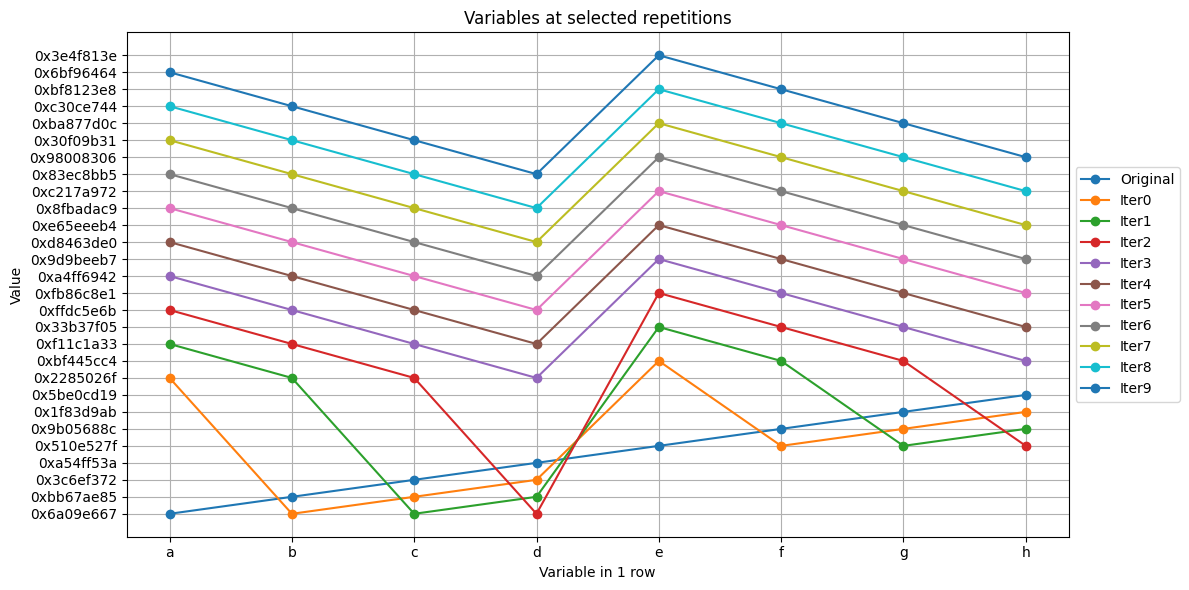

In [36]:
# 1st row
import matplotlib.pyplot as plt
row = 1
variables = ['a','b','c','d','e','f','g','h']

# 그리고 싶은 반복만 선택
selected_repeats = [40, 41, 42, 43, 45, 50, 51, 52, 53, 55, 60, 61, 62, 63]
selected_repeats = range(0, 10)

plt.figure(figsize=(12,6))

# Original 값 먼저 그림
row_values = df.iloc[row][variables].values
plt.plot(variables, row_values, marker='o', label='Original')

# 선택한 반복만 그림
for r in selected_repeats:
    repeat_vars = [f'I{r}_{v}' for v in variables]  # r 반복 후 변수 이름
    print(repeat_vars)
    row_values = df.iloc[row][repeat_vars].values
    plt.plot(variables, row_values, marker='o', label=f'Iter{r}')
    print(row_values)

plt.xlabel(f'Variable in {row} row')
plt.ylabel('Value')
plt.title('Variables at selected repetitions')
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


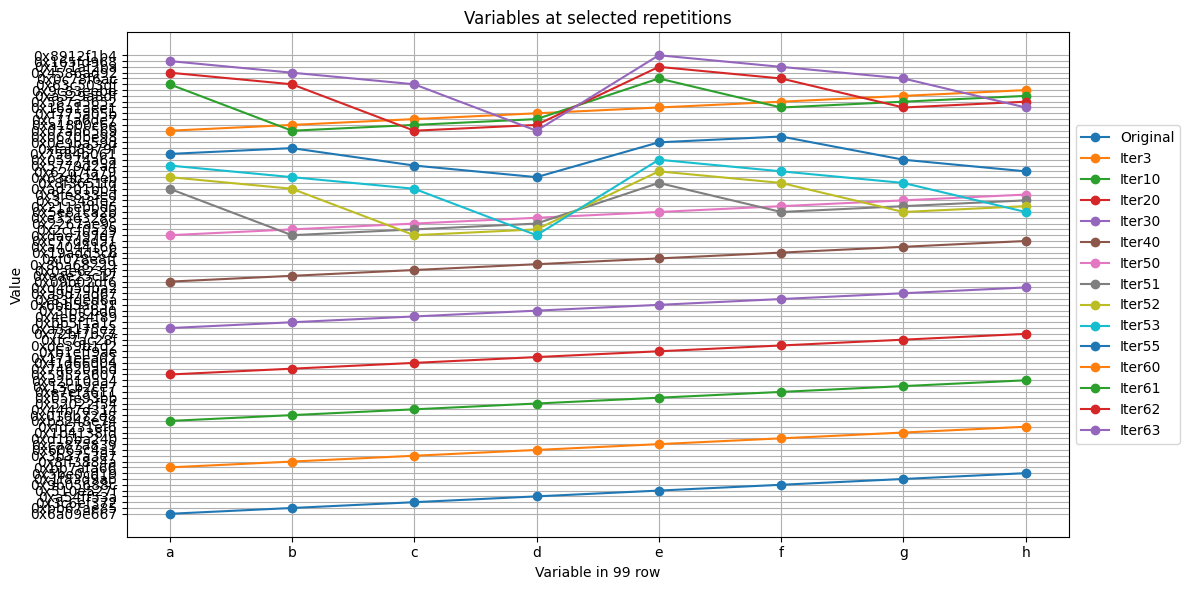

In [24]:
# 99th row
import matplotlib.pyplot as plt
row = 99
variables = ['a','b','c','d','e','f','g','h']

# 그리고 싶은 반복만 선택
selected_repeats = [3, 10, 20, 30, 40, 50, 51, 52, 53, 55, 60, 61, 62, 63]

plt.figure(figsize=(12,6))

# Original 값 먼저 그림
row_values = df.iloc[row][variables].values
plt.plot(variables, row_values, marker='o', label='Original')

# 선택한 반복만 그림
for r in selected_repeats:
    repeat_vars = [f'I{r}_{v}' for v in variables]  # r 반복 후 변수 이름
    row_values = df.iloc[row][repeat_vars].values
    plt.plot(variables, row_values, marker='o', label=f'Iter{r}')

plt.xlabel(f'Variable in {row} row')
plt.ylabel('Value')
plt.title('Variables at selected repetitions')
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


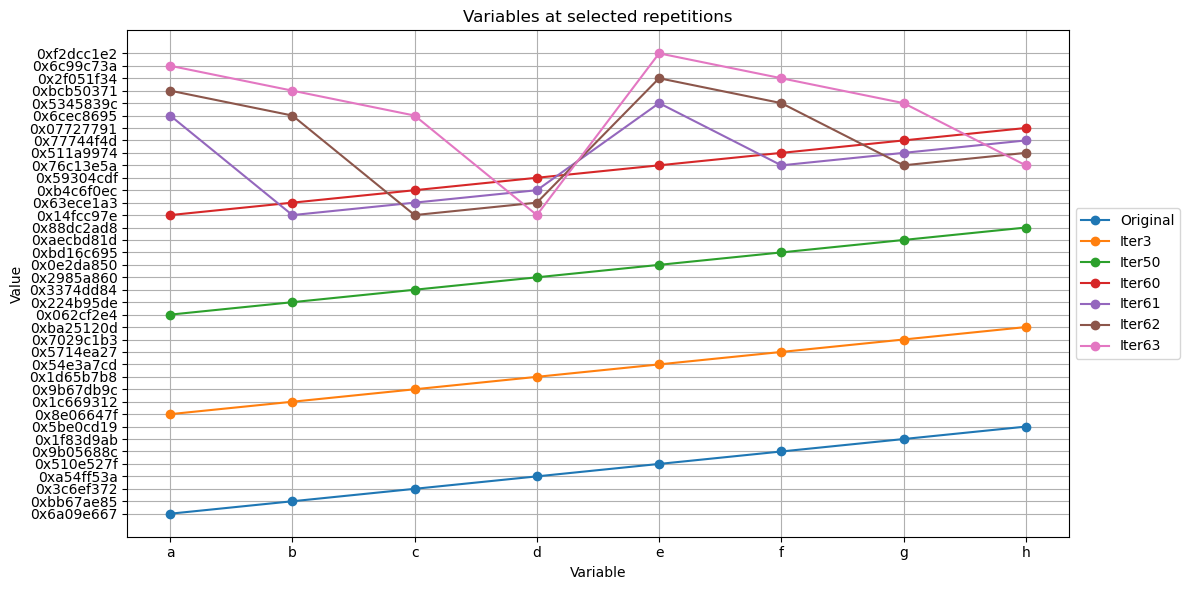

In [55]:
# 1st row
import matplotlib.pyplot as plt

variables = ['a','b','c','d','e','f','g','h']

# 그리고 싶은 반복만 선택
selected_repeats = [3, 50, 60, 61,62, 63]

plt.figure(figsize=(12,6))

# Original 값 먼저 그림
row_values = df.iloc[0][variables].values
plt.plot(variables, row_values, marker='o', label='Original')

# 선택한 반복만 그림
for r in selected_repeats:
    repeat_vars = [f'I{r}_{v}' for v in variables]  # r 반복 후 변수 이름
    row_values = df.iloc[0][repeat_vars].values
    plt.plot(variables, row_values, marker='o', label=f'Iter{r}')

plt.xlabel('Variable')
plt.ylabel('Value')
plt.title('Variables at selected repetitions')
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


### 2nd row

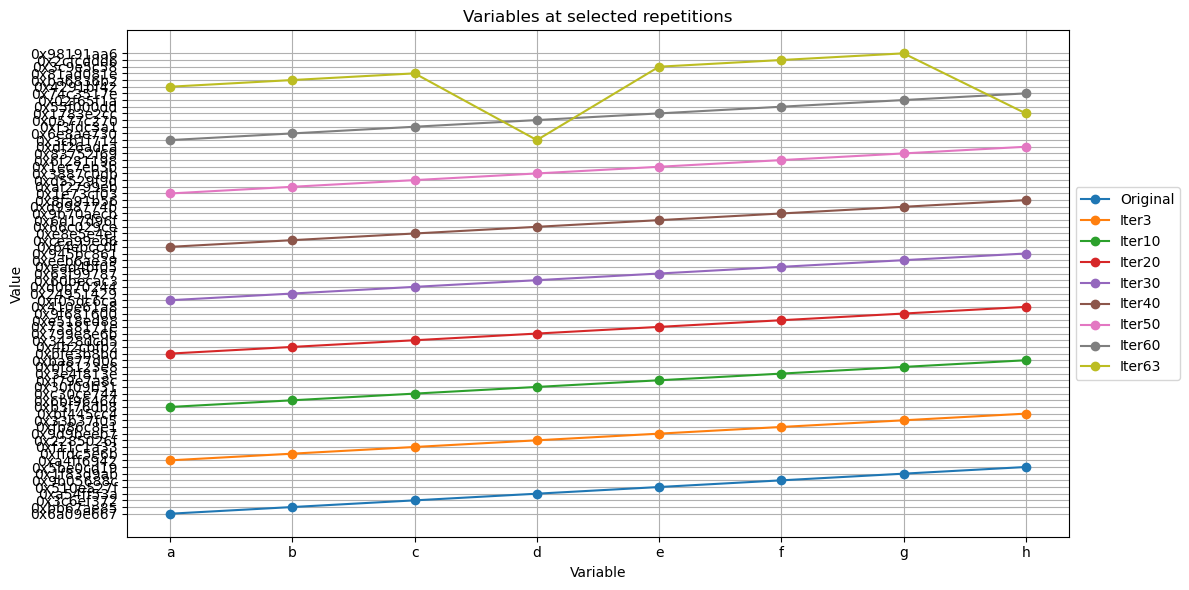

In [52]:
# 2st row
import matplotlib.pyplot as plt

variables = ['a','b','c','d','e','f','g','h']

# 그리고 싶은 반복만 선택
selected_repeats = [3, 10, 20, 30, 40, 50, 60, 63]

plt.figure(figsize=(12,6))

# Original 값 먼저 그림
row_values = df.iloc[1][variables].values
plt.plot(variables, row_values, marker='o', label='Original')

# 선택한 반복만 그림
for r in selected_repeats:
    repeat_vars = [f'I{r}_{v}' for v in variables]  # r 반복 후 변수 이름
    row_values = df.iloc[1][repeat_vars].values
    plt.plot(variables, row_values, marker='o', label=f'Iter{r}')

plt.xlabel('Variable')
plt.ylabel('Value')
plt.title('Variables at selected repetitions')
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


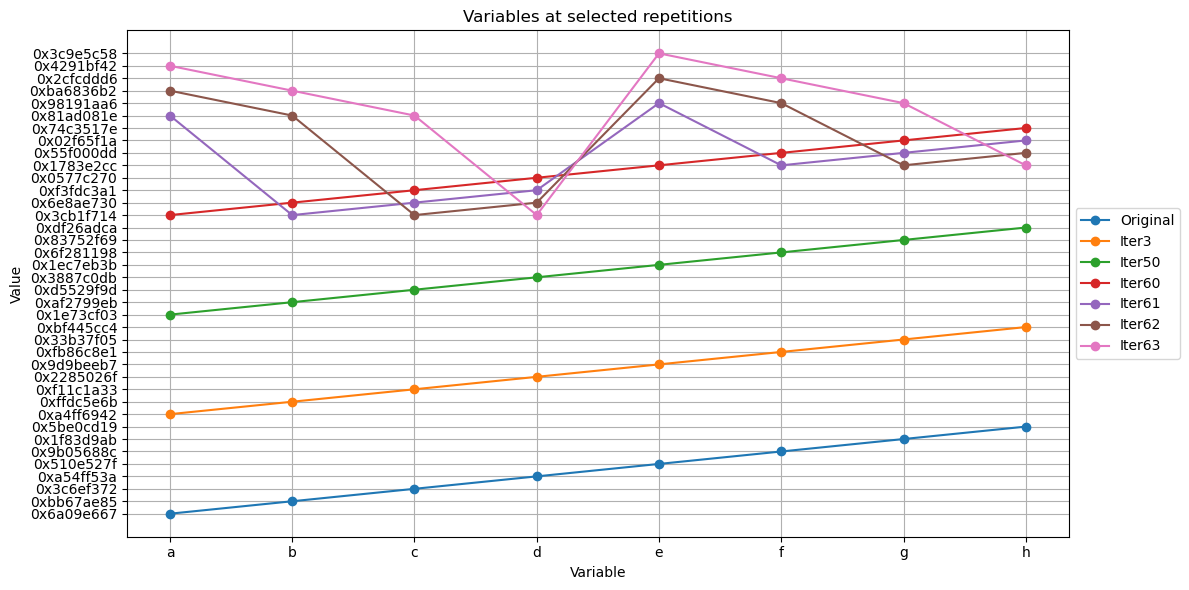

In [56]:
# 2st row
import matplotlib.pyplot as plt

variables = ['a','b','c','d','e','f','g','h']

# 그리고 싶은 반복만 선택
selected_repeats = [3, 50, 60, 61,62, 63]

plt.figure(figsize=(12,6))

# Original 값 먼저 그림
row_values = df.iloc[1][variables].values
plt.plot(variables, row_values, marker='o', label='Original')

# 선택한 반복만 그림
for r in selected_repeats:
    repeat_vars = [f'I{r}_{v}' for v in variables]  # r 반복 후 변수 이름
    row_values = df.iloc[1][repeat_vars].values
    plt.plot(variables, row_values, marker='o', label=f'Iter{r}')

plt.xlabel('Variable')
plt.ylabel('Value')
plt.title('Variables at selected repetitions')
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()
